This notebook and saves an ortho on the shendure data as preprocessed in `preprocessing` & demonstrates that estimated nb parameters track closely with UMI means, as expected.


# Setup

In [1]:
#imports
import pandas as pd
import numpy as np
import time
import pickle
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

2026-03-06 20:33:39.391857: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 20:33:39.395072: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [ ]:
#create dask cluster

from dask_jobqueue import SLURMCluster
from dask.distributed import Client

local=True
if not local:
    cluster=SLURMCluster(
        cores=8,#cores per slurm job
        memory="48G",#memory per slurm job
        processes=8,#dask workers per slurm job
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=6:00:00",
            f"--output=worker_%j.out"]
    )

    cluster.scale(jobs=3)

    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )
else:
    from dask.distributed import Client, LocalCluster
    cluster=LocalCluster()
    client = Client(cluster)

2026-03-06 20:33:48,949 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='a1132u07n04.mghpcc.ycrc.yale.edu:57215', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "/home/mcn26/.conda/envs/env_tzinb/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-t

In [3]:
client.dashboard_link

'http://127.0.0.1:8787/status'

# Describe with an ortho

Set paths

In [4]:
data_root="/nfs/roberts/project/pi_skr2/shared/tabula_data"
path=f"{data_root}/shendure"
name="shendure_ortho_20260306"

Next, clean the data format

In [ ]:
shendure_data_raw=pd.read_csv(f"{path}/shendure_counts_not_grouped.txt",sep="\t")

In [ ]:
cols=list(scm.MPRA_UMIWISE_ALLOWED)
cols.remove("reads_DNA")
cols

In [ ]:
shendure_data_reduced=shendure_data_raw[cols]
shendure_data_reduced.to_csv(f"{path}/shendure_processed.tsv",sep="\t", index=False)

In [5]:
if os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
else:
    print("[+] Model not found. Creating...")

    #load data
    shendure=scm.scMPRA_data.from_tsv(f"{path}/shendure_processed.tsv")
    shendure.set_negative_controls(["minP","noP"])
    shendure.set_reference_cell("Pluripotent")
    shendure.ortho_filter()

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                       dat=shendure)
    primordial.extract_params(client)
    primordial.save(path,name)


[+] Model found. Loading...


# Examine QC metrics

In [6]:
primordial.compute_model_qc()

In [7]:
by_cre_thetas=[]
for key in primordial.by_cre.model:
    by_cre_thetas.append(primordial.by_cre.model[key].result()["weights"]["theta"].squeeze())
by_cre_thetas=np.array(by_cre_thetas)

by_cell_type_thetas=[]
for key in primordial.by_cell_type.model:
    by_cell_type_thetas.append(primordial.by_cell_type.model[key].result()["weights"]["theta"].squeeze())
by_cell_type_thetas=np.array(by_cell_type_thetas)


<Axes: >

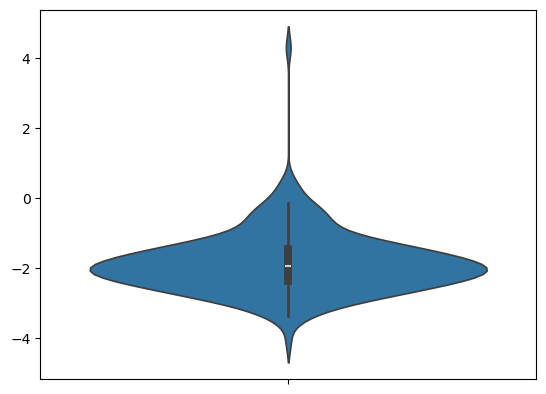

In [8]:
sns.violinplot(by_cre_thetas)

<Axes: >

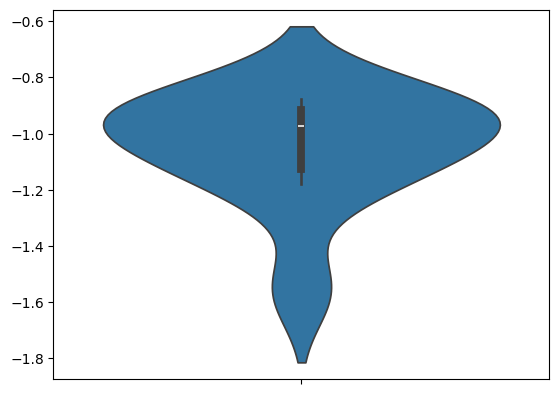

In [9]:
sns.violinplot(by_cell_type_thetas)

In [10]:
np.mean(by_cre_thetas)

-1.8600496

In [11]:
np.mean(by_cell_type_thetas)

-1.0525941

In [12]:
np.mean(np.concatenate((by_cre_thetas,by_cell_type_thetas)))

-1.8230103

Let's look at the mu min & max : none should be below zero, none should be above 1000.

In [13]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 0.004886557813733816, max 370.4069519042969
ct
min 0.0034699595998972654, max 343.5565490722656


All in the right ballpark!

Now let's look at the correlations.

---
low r Cdk5r1_chr11_12595
low r Lamb1_chr12_2206
nan in Txndc12_chr4_7969
low r Lamc1_chr1_12183
---
[0.999831593807072, 0.9999963784346863, 0.9999742760156347, 0.9999727759495964, 0.9998296649744014, 0.9993737764777525, 0.999999223821548, 0.9994458218881132, 0.9996153264870543, 0.9990036192047894, 0.9950353166032452, 0.9999995838065681, 0.9996768547496704, 0.998689707794701, 0.9998285058201752, 0.999466695118729, 0.9989283606903968, 0.9970899752667591, 0.9996618554094479, 0.9997320931312967, 0.9999553212027557, 0.9979665010187533, 0.999918866935985, 0.9956220723233951, 0.9846425180526313, 0.9997938376368439, 0.9999532863547245, 0.9989229880584644, 0.9965634628714534, 0.9996575898305193, 0.9699998168552808, 0.9983620293817281, 0.9996667229066241, 0.9998266884480027, 0.9928343861018707, 0.9999451567509364, 0.9999999733503786, 0.9990458772245197, 0.9995689514324949, 0.9970543184919073, 0.9991336999668717, 0.9999896065003177, 0.99804449403517, 0.9991033756554963, 0.9966305064712977, 0.

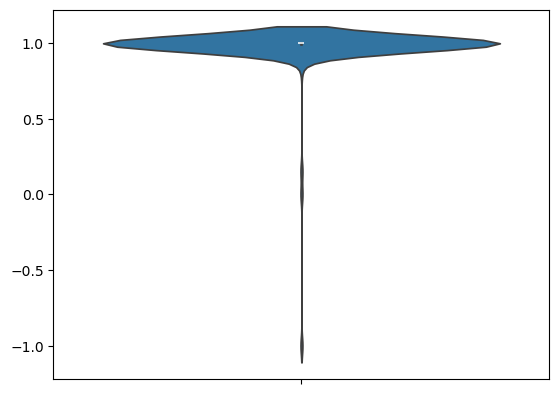

In [14]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

Correlations generally look pretty good. Let's examine the cases where they aren't.

Notably all of the bad ones are from the set of "by cell-type" models.

I'm going to guess these are low-expressing CREs. Let's take a look.

In [15]:
highlighted_cre_ids=["Cdk5r1_chr11_12595","Lamb1_chr12_2206","Lamc1_chr1_12183","Txndc12_chr4_7969"]

grouped = (
    shendure.data
    .groupby(["cre_id", "cell_type"])["umis_mpra_bc"]
    .mean()
    .reset_index()
)

# Split base vs. highlighted
base = grouped[~grouped["cre_id"].isin(highlighted_cre_ids)]
highlighted = grouped[grouped["cre_id"].isin(highlighted_cre_ids)]

# Set up plot
plt.figure(figsize=(10, 6))

# Plot base layer with jitter
sns.stripplot(
    data=base,
    x="cell_type",
    y="umis_mpra_bc",
    color="lightgray",
    jitter=0.35,
    label="Other CREs",
    size=6
)

# Overlay highlighted CREs with jitter and custom color
palette = sns.color_palette("tab10", n_colors=len(highlighted_cre_ids))
for i, cre in enumerate(highlighted_cre_ids):
    sns.stripplot(
        data=highlighted[highlighted["cre_id"] == cre],
        x="cell_type",
        y="umis_mpra_bc",
        color=palette[i],
        jitter=0.35,
        label=cre,
        size=6
    )

# Y-axis and aesthetics
plt.ylim(-1, 1)
plt.xlabel("Cell Type")
plt.ylabel("Mean UMIs (mpra_bc)")
plt.title("Mean UMIs per (cre_id, cell_type)")
plt.xticks(rotation=45)
plt.legend(title="Highlighted CREs")
plt.tight_layout()
plt.show()


RuntimeError: Encountered an exception when converting data source to a pandas DataFrame. See traceback above for details.

<Figure size 1000x600 with 0 Axes>

In [ ]:
primordial.by_cre_qc["Cdk5r1_chr11_12595"]

In [9]:
cluster.close()
client.close()